        A      <- 루트 노드
       / \
      B   C
     / \
    D   E
A가 루트 노드예요.

B, C, D, E는 루트 노드 A를 기준으로 연결된 자식 노드예요.

루트 노드에서 시작해서 아래로 뻗어나가는 구조를 트리라고 해요.

###########################################################

지니계수의 개념

정의: 한 노드 안에 섞여 있는 클래스(라벨)의 불순도를 나타내는 지표

값의 범위: 0 ~ 0.5 (2개의 클래스 기준)

0: 노드 안의 샘플이 모두 같은 클래스 → 완전히 순수

0.5: 노드 안의 샘플이 절반씩 섞여 있음 → 가장 불순

즉, 값이 작을수록 순수한 노드라는 뜻이에요.

###########################################################

결정트리의 예측원리 :
루트노드 부터 시작
각 노드의 질문에 따라 가지를 타고 내려가
최종 리프노드에 도달하여 예측값을 얻는과정

클래스 확률을 추정 :
특정데이터가 각 클래스에 속할 확률을 어떻게 계산하는지 설명

훈련 데이터에 너무 과하게 맞춰지는 과대적합(overfiting)을 막기 위한 파라미터들을 조정 -> 규세 하이퍼 파라미터

결정트리를 사용 가능 한곳 : 특정 수치를 예측하는 회귀 문제에 적용 가능 -> 불순도 대신 MSE 사용

불안정성
작은 변화에도 민감하게 반응해서 트리구조가 완전히 달라질 수 있다. -> 랜덤 포레스트 등장의 배경
-> 아마 이 단점을 보완하는 기능?

노드분할의 기준 : 지니계수 (Gini Impurity)

한 그룹(노드)에 얼마나 다른 데이터들이 섞여 있는가? 를 나타내는 지표
0 : 완전순수 : 한그룹에 하나의 클래스 : 상자에 파란공만

질문을 통해서 데이터를 나눌때 다음 그룹들의 지니불순도가 최대한 낮아지도록 하는 질문(지표)
![alt text](image.png)


In [ ]:
# 노드에 50개의 데이터가 붓꽃 : A 40 B 10
# A의 비율 : (Pa) = 40 / 50 = 0.2
# B의 비율 : (Pb) = 10 / 50 = 0.2
# 지니불순도 1 = (0)

In [ ]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier

# 데이터 셋 불러오기
iris = load_iris(as_frame=True)
X = iris.data.iloc[:,[2,3]] # 꽃잎의 길이, 너비
y = iris.target

# 모델 생성 및 학습
tree = DecisionTreeClassifier()
tree.fit(X,y)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [3]:
X.columns

Index(['petal length (cm)', 'petal width (cm)'], dtype='object')

[Text(0.5, 0.9166666666666666, 'petal length (cm) <= 2.45\ngini = 0.667\nsamples = 150\nvalue = [50, 50, 50]\nclass = setosa'),
 Text(0.4090909090909091, 0.75, 'gini = 0.0\nsamples = 50\nvalue = [50, 0, 0]\nclass = setosa'),
 Text(0.4545454545454546, 0.8333333333333333, 'True  '),
 Text(0.5909090909090909, 0.75, 'petal width (cm) <= 1.75\ngini = 0.5\nsamples = 100\nvalue = [0, 50, 50]\nclass = versicolor'),
 Text(0.5454545454545454, 0.8333333333333333, '  False'),
 Text(0.36363636363636365, 0.5833333333333334, 'petal length (cm) <= 4.95\ngini = 0.168\nsamples = 54\nvalue = [0, 49, 5]\nclass = versicolor'),
 Text(0.18181818181818182, 0.4166666666666667, 'petal width (cm) <= 1.65\ngini = 0.041\nsamples = 48\nvalue = [0, 47, 1]\nclass = versicolor'),
 Text(0.09090909090909091, 0.25, 'gini = 0.0\nsamples = 47\nvalue = [0, 47, 0]\nclass = versicolor'),
 Text(0.2727272727272727, 0.25, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 1]\nclass = virginica'),
 Text(0.5454545454545454, 0.41666666666666

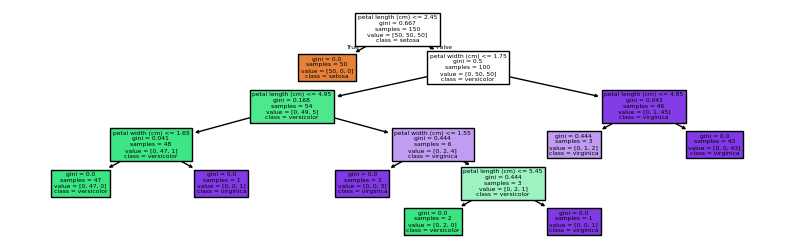

In [6]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree # ^
plt.figure(figsize=(10,3))
plot_tree(tree,feature_names=X.columns,class_names = iris.target_names, filled=True)